**1-Importing Needed Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2-Reading data and getting background info / statistics / shape about it**


In [2]:
data = pd.read_csv('/content/drive/MyDrive/Cellula_Data/final_internship_data.csv')
print(data.shape)

(500000, 26)


In [3]:
#Info about data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [4]:
#Descriptive statistics about data
data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


**3-Data Cleaning**

In [5]:
"""A-Check Duplicates and remove if found"""

print("Duplicate keys:", data['key'].duplicated().sum())
data = data.drop_duplicates(subset='key')

Duplicate keys: 0


In [6]:
"""B-Remove Costing Features"""
data = data.drop(columns=['User ID', 'User Name', 'Driver Name', 'key'])

In [7]:
#Check Columns are dropped
data.shape

(500000, 22)

In [8]:
"""C-Handling null values"""

print(data.isnull().sum())
#get the percentage of nulls in data to decide the approach to be taken handling nulls
print("\npercentage:\n", (data.isnull().sum() / len(data)) * 100)

Car Condition        0
Weather              0
Traffic Condition    0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

percentage:
 Car Condition        0.000
Weather              0.000
Traffic Condition    0.000
fare_amount          0.000
pickup_datetime      0.000
pickup_longitude     0.000
pickup_latitude      0.000
dropoff_longitude    0.001
dropoff_latitude     0.001
passenger_count      0.000
hour                 0.000
day                  0.000
month                0.000
weekday              0.000
year                 0.000
jfk_dist             0.001
ewr_dist             0.001
lga_dist

In [9]:
#Dropping nulls
data=data.dropna()
data.shape

(499995, 22)

In [10]:
"""D-Handling inappropriate values in some columns"""

cols = [
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'distance',
    'bearing'
]

data = data[(data[cols] != 0).all(axis=1)]
data.shape

(484787, 22)

In [11]:
#Rounding up some values
cols1 = [
    'distance',
    'jfk_dist',
    'ewr_dist',
    'lga_dist',
    'sol_dist',
    'nyc_dist'
]

data[cols1] = data[cols1].round(2)

In [12]:
#Check all fare amounts are positive
data = data[data['fare_amount'] > 0]
data.shape

(484757, 22)

In [13]:
#Check no of customers not to equal zero
data = data[data['passenger_count'] > 0]
data.shape

(483011, 22)

In [14]:
data = data[data['distance'] > 0]
data.shape

(482121, 22)

In [15]:
#Ensure pickup_datetime is a DateTime object not just normal string
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
print(data['pickup_datetime'].dtype)

datetime64[ns]


In [16]:
#Change values of these columns for better visualization
coord_cols = ['pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude']

data[coord_cols] = data[coord_cols].apply(np.degrees)

print(data[coord_cols].describe())

       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude
count     482121.000000    482121.000000      482121.000000     482121.000000
mean         -73.914547        40.691832         -73.920553         40.682862
std            6.310080         3.897081           6.254354          4.985506
min        -2986.242495      -880.627428       -3383.296608      -2559.748913
25%          -73.992268        40.736549         -73.991564         40.735600
50%          -73.982098        40.753383         -73.980602         40.753887
75%          -73.968466        40.767482         -73.965408         40.768420
max         2140.601160      1703.092772          40.851027        404.616667


In [17]:
#Change bearings from radians to degrees and ensuring values are between 0 to 360
data['bearing'] = np.degrees(data['bearing'])
data['bearing'] = (data['bearing'] + 360) % 360
print(data['bearing'].min(), data['bearing'].max())

0.0022550697361225502 359.9999906984909


In [18]:
#Since the Dataset is on trips happened in New York City
"""Check that boundaries of all trips are actually in New York City Boundaries (Not an Outlier)"""
# Approximate geographic boundaries of New York City (retrieved from google)
# Longitude: -74.3 to -72.9
# Latitude: 40.5 to 41.8
nyc_bounds = {
    'lon_min': -74.3, 'lon_max': -72.9,
    'lat_min': 40.5, 'lat_max': 41.8
}

valid_mask = (
    data['pickup_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    data['pickup_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max']) &
    data['dropoff_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    data['dropoff_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max'])
)

print("Rows outside NYC bounds:", len(data) - valid_mask.sum())
data = data[valid_mask]
data.shape

Rows outside NYC bounds: 606


(481515, 22)

In [19]:
#Rounding them up to 4 decimals
coord_cols1 = ['pickup_longitude', 'pickup_latitude',
              'dropoff_longitude', 'dropoff_latitude']

data[coord_cols1] = data[coord_cols1].round(4)

# Rounding bearing to 2 decimals
data['bearing'] = data['bearing'].round(2)

In [20]:
#Renaming Day and adding day of the week
data = data.rename(columns={'day': 'day_of_month'})

In [21]:
#refining the names of the columns
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [22]:
#remove very short rides with high fare amount (outliers)
data = data[~((data['distance'] < 1) & (data['fare_amount'] > 100))]
print("New shape:", data.shape)

New shape: (481501, 22)


In [23]:
#remove very long trips with very low fare amounts (outliers)
data = data[~((data['distance'] > 50) & (data['fare_amount'] < 20))]
data.shape

(481437, 22)

In [24]:
data.head(10)

,car_condition,weather,traffic_condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-73.8443,40.7213,-73.8416,40.7123,1,...,6,0,2009,20.27,55.18,14.34,34.54,27.57,1.03,192.76
1,Excellent,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-74.0160,40.7113,-73.9793,40.7820,1,...,1,1,2010,44.67,31.83,23.13,15.13,8.76,8.45,338.50
2,Bad,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-73.9827,40.7613,-73.9912,40.7506,2,...,8,3,2011,43.60,33.71,19.87,17.72,9.85,1.39,148.97
3,Very Good,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-73.9871,40.7331,-73.9916,40.7581,1,...,4,5,2012,42.64,32.56,21.06,15.74,7.70,2.80,7.67
4,Bad,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-73.9681,40.7680,-73.9567,40.7838,1,...,3,1,2010,43.33,39.41,15.22,23.73,15.60,2.00,331.20
5,Excellent,sunny,Congested Traffic,12.1,2011-01-06 09:50:45,-74.0010,40.7316,-73.9729,40.7582,1,...,1,3,2011,42.34,32.82,20.65,15.74,7.65,3.79,321.37
6,Excellent,windy,Flow Traffic,7.5,2012-11-20 20:35:00,-73.9800,40.7517,-73.9738,40.7648,1,...,11,1,2012,42.56,35.48,18.11,19.13,10.99,1.56,340.39
7,Good,sunny,Congested Traffic,16.5,2012-01-04 17:22:00,-73.9513,40.7741,-73.9901,40.7510,1,...,1,2,2012,42.53,36.83,16.95,20.55,12.45,4.16,128.15
8,Excellent,rainy,Dense Traffic,9.0,2012-12-03 13:10:00,-74.0065,40.7267,-73.9931,40.7316,1,...,12,0,2012,42.24,29.61,23.94,11.67,3.64,1.25,295.86
9,Very Good,sunny,Dense Traffic,8.9,2009-09-02 01:11:00,-73.9807,40.7339,-73.9915,40.7581,2,...,9,2,2009,42.22,33.11,20.54,16.19,8.13,2.85,18.76


In [25]:
data.describe()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_month,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,481437.000000,481437,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000,481437.000000
mean,11.309387,2012-03-22 21:54:07.904481792,-73.975574,40.750914,-73.974530,40.751353,1.690514,13.514697,15.677063,6.272173,3.041669,2011.744087,41.853551,35.598972,19.511280,18.827434,11.080781,3.364741,206.106725
min,0.010000,2009-01-01 00:31:32,-74.295500,40.508600,-74.294600,40.505600,1.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.020000,1.460000,0.380000,0.530000,0.140000,0.010000,0.000000
25%,6.000000,2010-08-16 17:16:00,-73.992300,40.736600,-73.991600,40.735700,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.320000,32.120000,17.050000,14.800000,7.070000,1.280000,136.440000
50%,8.500000,2012-03-24 00:41:00,-73.982100,40.753400,-73.980600,40.753900,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.480000,34.660000,19.490000,18.190000,10.310000,2.180000,188.480000
75%,12.500000,2013-10-24 06:35:00,-73.968500,40.767500,-73.965500,40.768400,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.670000,38.020000,22.010000,22.100000,14.130000,3.960000,315.750000
max,281.050000,2015-06-30 23:38:21,-73.131200,41.523200,-73.091000,41.543200,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,199.840000,205.900000,172.090000,198.790000,191.500000,110.830000,360.000000
std,9.453547,NaN,0.034652,0.026989,0.034552,0.030917,1.306268,6.508727,8.681590,3.439750,1.948808,1.867129,4.482297,5.325244,4.146192,5.726117,5.738592,3.625137,104.036735


In [26]:
data.shape

(481437, 22)

In [27]:
#add the cleaned Dataset to drive
data.to_csv('/content/drive/MyDrive/Cellula_Data/final_internship_data_cleaned.csv', index=False)

**4-Analysis**

### Q1) Is higher passenger count associated with higher fare?
**Variables:** passenger_count (numerical) vs fare_amount (numerical)

**Suitable plot:** Boxplot,I have chosen it over the initial scatter plot because scatter visually overweights groups with more data points, which is misleading when group sizes are unequal.

In [28]:
# Supporting evidence that scatter
#1-no of trips per each passenger count
print(data['passenger_count'].value_counts().sort_index())
#2-Average fare amount per passenger count
print(data.groupby('passenger_count')['fare_amount'].mean())

passenger_count
1    334040
2     71665
3     21089
4     10260
5     34099
6     10284
Name: count, dtype: int64
passenger_count
1    11.159388
2    11.791819
3    11.471162
4    11.716547
5    11.222010
6    12.371462
Name: fare_amount, dtype: float64


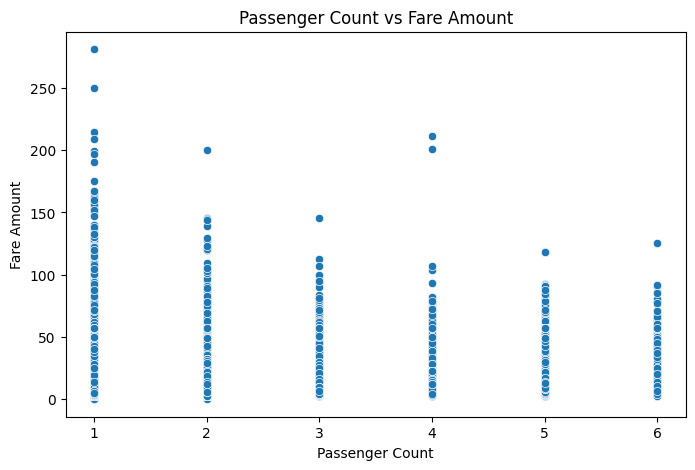

In [29]:
#scatter plot firstly
plt.figure(figsize=(8,5))
sns.scatterplot(x='passenger_count', y='fare_amount', data=data)

plt.title('Passenger Count vs Fare Amount')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')

plt.show()
#it shows you that 1 passenger gets more fare amount , but it's only because the no of trips

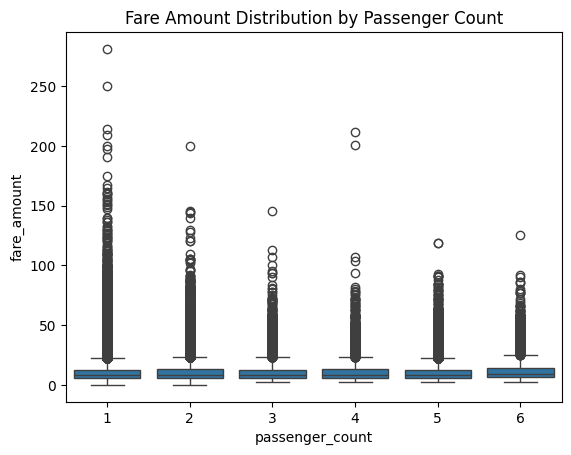

In [30]:
#Boxplot
sns.boxplot(x='passenger_count', y='fare_amount', data=data)
plt.title('Fare Amount Distribution by Passenger Count')
plt.show()

**Insight**: Passenger count has little to no effect on fare amount. Although rides with 1 passenger appeared to have higher fares, this is because they account for 334,091 rides (69% of the dataset), compared with only 10,262 rides for 4 passengers. The average fare is very similar across all passenger counts ($11.16–$12.37), showing that fare mainly depends on distance, not the number of passengers.

### Q2)  Does car condition influence the fare amount?
**Variables:** Car condition (categorical) vs fare_amount (numerical)

**Suitable plot:** Bar Chart as no of trips are close this time for each group

In [31]:
#ensuring groups no are close
print(data['car_condition'].value_counts())

car_condition
Very Good    120608
Bad          120341
Good         120318
Excellent    120170
Name: count, dtype: int64


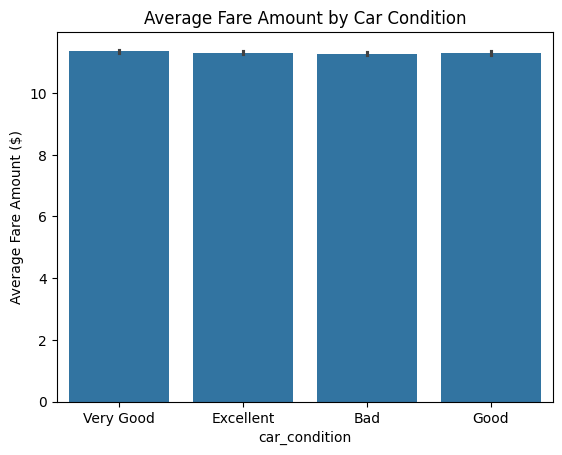

In [32]:
sns.barplot(data=data, x='car_condition', y='fare_amount')

plt.title('Average Fare Amount by Car Condition')
plt.ylabel('Average Fare Amount ($)')
plt.show()

**Insight:** Car condition has little to no effect on fare amount. The average fare is almost the same across all conditions (Very Good, Excellent, Bad, and Good), ranging from $11.2–$11.4, and each category contains about 120,000 rides, so the comparison is fair. This is expected because ride fares depend on distance, time, and demand, not the car's condition.

### Q3) At what hour of the day are fares typically highest?
**Variables:** hour (numerical) vs fare_amount (numerical)

**Suitable plot:** Line chart  chosen because it's best for time series

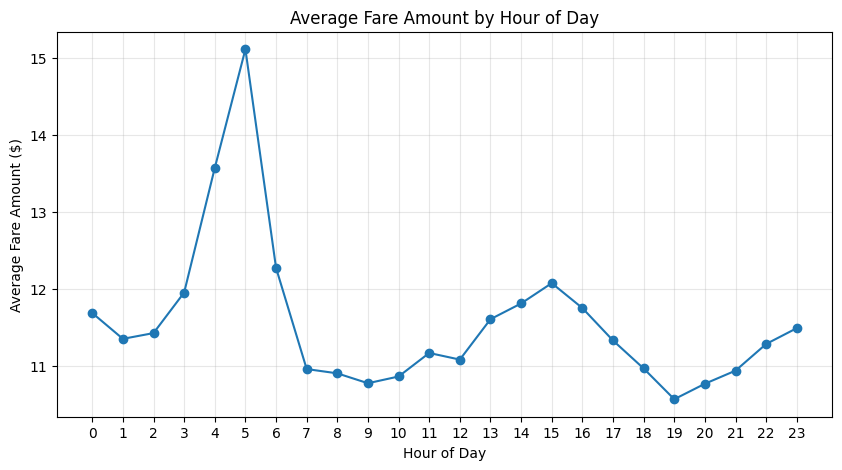

In [33]:
import matplotlib.pyplot as plt

avg_fare_by_hour = data.groupby('hour')['fare_amount'].mean()

plt.figure(figsize=(10, 5))
avg_fare_by_hour.plot(kind='line', marker='o')
plt.title('Average Fare Amount by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

In [34]:
# After plotting fare by hour, checking if the pattern is really about distance  rather than hour itself
# value counts confirms group sizes are reliable
# and mean distance by hour shows whether fare and distance follow the same trend or not
#if they follow the same trend it will show that the fare pattern isn't really about the hour itself
#it's just reflecting that trips happen to be longer at certain hours
print(data['hour'].value_counts().sort_index())
print(data.groupby('hour')['distance'].mean())


hour
0     18885
1     13995
2     10468
3      7601
4      5600
5      4752
6      9949
7     17547
8     21794
9     22742
10    21625
11    22510
12    23739
13    23478
14    24464
15    23164
16    19766
17    23699
18    28981
19    30214
20    28164
21    27564
22    26785
23    23951
Name: count, dtype: int64
hour
0     3.846255
1     3.777920
2     3.876675
3     4.091716
4     4.738446
5     5.316566
6     4.170046
7     3.438462
8     3.060453
9     2.926426
10    3.001908
11    3.073390
12    3.005127
13    3.220427
14    3.253214
15    3.398330
16    3.362953
17    3.213398
18    3.079393
19    3.079294
20    3.310538
21    3.419925
22    3.584252
23    3.677388
Name: distance, dtype: float64


**Insight:** Fare appears to vary by hour, but this is driven by trip distance mainly.


### Q4: Does traffic condition affect the trip fare?
**Variables:** traffic_condition (categorical) vs fare_amount (numerical)

**Suitable plot:** Bar chart (average fare per category)

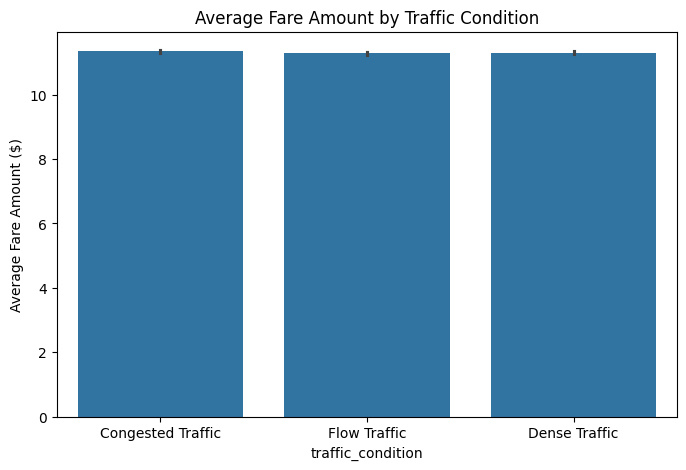

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='traffic_condition', y='fare_amount')
plt.title('Average Fare Amount by Traffic Condition')
plt.ylabel('Average Fare Amount ($)')
plt.show()

In [36]:
#check group numbers are reliable
print(data['traffic_condition'].value_counts())
print(data.groupby('traffic_condition')['fare_amount'].agg(['mean', 'median', 'std', 'count']))

traffic_condition
Congested Traffic    160675
Flow Traffic         160394
Dense Traffic        160368
Name: count, dtype: int64
                        mean  median       std   count
traffic_condition                                     
Congested Traffic  11.343740     8.5  9.563560  160675
Dense Traffic      11.302716     8.5  9.405930  160368
Flow Traffic       11.281643     8.5  9.389929  160394


**Insight:** Traffic condition has no real effect on fare amount. All three categories have an average fare of approximately 11.3$ and the same median with close no of group sizes

**Q5: Is trip distance the strongest predictor of fare amount?**

Variables: distance (numerical) vs fare_amount (numerical)

Plot: Scatter plot , best for relationships between 2 variables


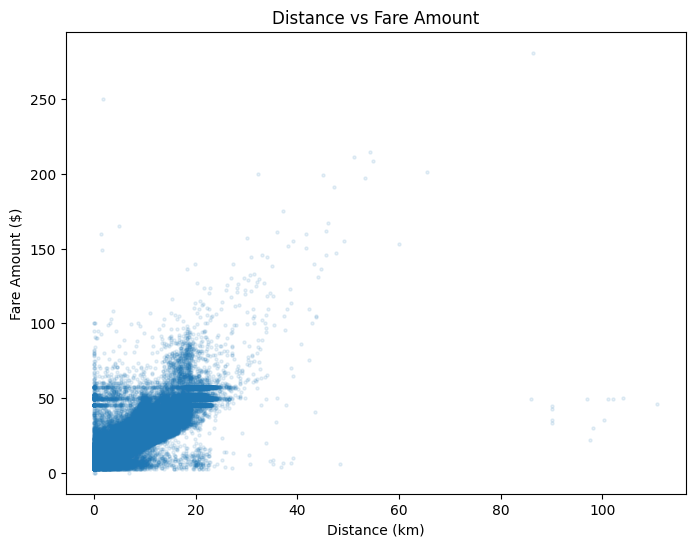

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(data['distance'], data['fare_amount'], alpha=0.1, s=5)
plt.title('Distance vs Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

In [38]:
#Calculate the correlation between the two variables for more ensurance (Pearson correlation coefficient)
print(data[['distance', 'fare_amount']].corr())

             distance  fare_amount
distance     1.000000     0.886002
fare_amount  0.886002     1.000000


**Insight:** Distance is the strongest predictor of fare found so far with correlation of 88.6% ,so far it is stronger than passenger count, car condition, or traffic condition (all have no effect). The scatter shows a clear positive trend, fare rises with distance especially up to ~20km. This confirms the pattern from Q1-Q4: those other factors appeared to affect fare only because they were indirectly tied to distance.

**Q6: At what time of day are ride requests most frequent?**

Variables: hour (numerical) vs ride count (frequency)

Plot: Count plot, because it's best for frequency of categories

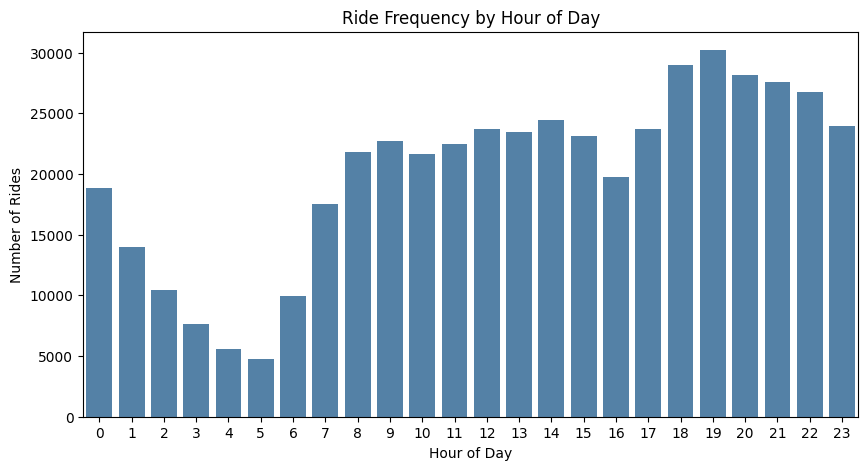

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='hour', color='steelblue')
plt.title('Ride Frequency by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.show()

**Insight:** Ride demand is highest in the evening (6-10 PM) with about 27K–30K rides per hour, and lowest at 4-5 AM with about 5K rides per hour. This is the opposite of the fare pattern in Q3, where fares were highest at 5 AM, showing that the higher fares were due to longer trip distances, not higher demand.

weather
sunny     96700
rainy     96336
stormy    96264
cloudy    96232
windy     95905
Name: count, dtype: int64
             mean  median       std  count
weather                                   
cloudy   3.364177    2.17  3.655552  96232
rainy    3.360019    2.19  3.596052  96336
stormy   3.365144    2.18  3.608727  96264
sunny    3.374407    2.19  3.643496  96700
windy    3.359900    2.18  3.621517  95905


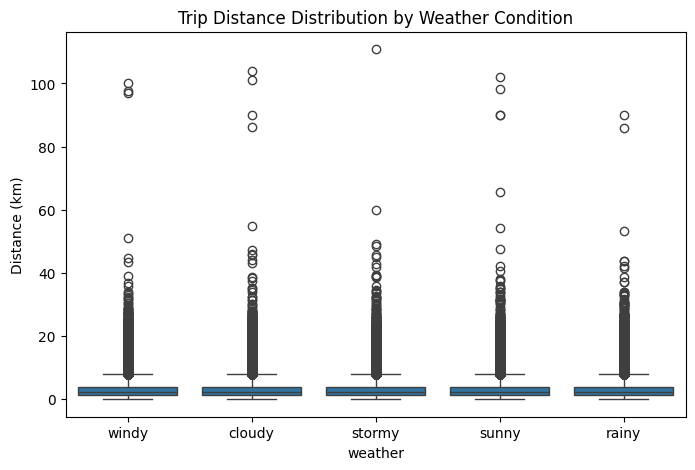

In [40]:
print(data['weather'].value_counts())
print(data.groupby('weather')['distance'].agg(['mean', 'median', 'std', 'count']))

plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='weather', y='distance')
plt.title('Trip Distance Distribution by Weather Condition')
plt.ylabel('Distance (km)')
plt.show()

**Insight:** Weather has little to no effect on trip distance. The average trip distance is almost the same in all five weather conditions (3.36-3.37 km), with similar medians (2.18-2.19 km) and about 96K rides in each group. People travel about the same distance regardless of the weather.

**Q8: Are rides that start closer to airports generally more expensive?**

Variables: jfk_dist, ewr_dist, lga_dist (numerical) vs fare_amount (numerical)

Plot: Scatter plot, Best for relationships between variables

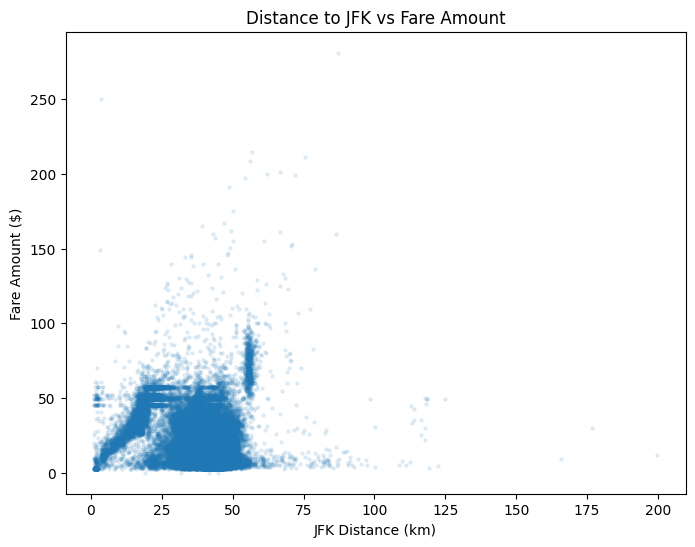

             jfk_dist  fare_amount
jfk_dist      1.00000     -0.46787
fare_amount  -0.46787      1.00000


In [41]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['jfk_dist'], data['fare_amount'], alpha=0.1, s=5)
plt.title('Distance to JFK vs Fare Amount')
plt.xlabel('JFK Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

print(data[['jfk_dist', 'fare_amount']].corr())

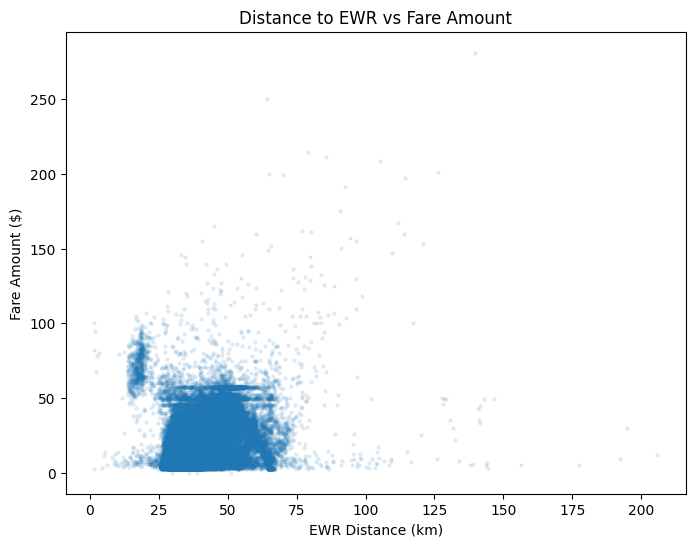

             ewr_dist  fare_amount
ewr_dist     1.000000     0.411078
fare_amount  0.411078     1.000000


In [42]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['ewr_dist'], data['fare_amount'], alpha=0.1, s=5)
plt.title('Distance to EWR vs Fare Amount')
plt.xlabel('EWR Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

print(data[['ewr_dist', 'fare_amount']].corr())

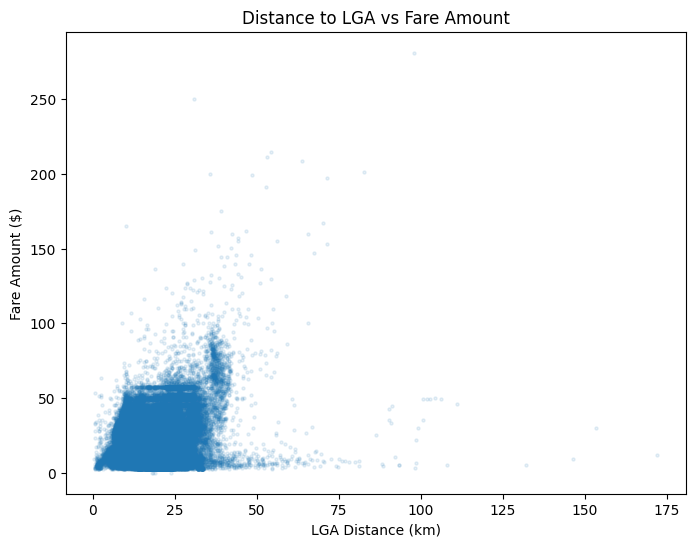

             lga_dist  fare_amount
lga_dist     1.000000     0.106116
fare_amount  0.106116     1.000000


In [43]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(data['lga_dist'], data['fare_amount'], alpha=0.1, s=5)
plt.title('Distance to LGA vs Fare Amount')
plt.xlabel('LGA Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

print(data[['lga_dist', 'fare_amount']].corr())

In [44]:
# Compare airport-area trips vs other trips, across all 3 airports
airport_cols = {'jfk_dist': 'JFK', 'ewr_dist': 'EWR', 'lga_dist': 'LGA'}

results = []
for col, name in airport_cols.items():
    airport_trips = data[data[col] < 2]
    non_airport = data[data[col] >= 2]
    results.append({
        'Airport': name,
        'Airport_area_avg_fare': airport_trips['fare_amount'].mean(),
        'Airport_area_count': len(airport_trips),
        'Other_trips_avg_fare': non_airport['fare_amount'].mean()
    })

print(pd.DataFrame(results))

  Airport  Airport_area_avg_fare  Airport_area_count  Other_trips_avg_fare
0     JFK              14.609449                 127             11.308516
1     EWR              61.500000                   3             11.309074
2     LGA               8.792589                 112             11.309973


**Insight:** Correlation between fare and distance-to-airport varies by airport: JFK is negative (-0.47), LGA is weakly positive (0.11), EWR is moderately positive (0.41) — no consistent pattern. But looking at actual airport-area trips (within 2km) vs other trips tells the real story: JFK trips cost more (14.61 vs 11.31), LGA trips cost less (8.79 vs 11.31), and EWR (only 3 trips) isn't reliable. Airport proximity itself doesn't drive fare — trip distance does, and each airport just happens to be associated with different typical trip lengths.

Extra Q1

Q: Are weekend fares different from weekday fares?

Variables: is_weekend (categorical / binary) vs fare_amount (numerical)

Chosen plot: Bar chart , reason: comparing average fare across two groups

                 mean  median   count
is_weekend                           
0           11.324972     8.5  345153
1           11.269916     8.5  136284


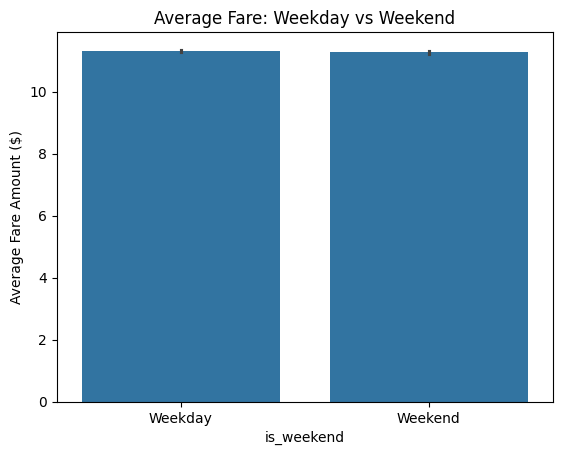

In [54]:
# binary flag: weekday column uses 0=Monday...6=Sunday
# so 5 and 6 correspond to Saturday and Sunday
data['is_weekend'] = data['weekday'].isin([5, 6]).astype(int)

# Compare average, median, and sample size between the two groups
# checking count ensures neither group is too small to trust
print(data.groupby('is_weekend')['fare_amount'].agg(['mean', 'median', 'count']))

# Bar chart to visually compare average fare between weekday and weekend
sns.barplot(data=data, x='is_weekend', y='fare_amount')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Average Fare: Weekday vs Weekend')
plt.ylabel('Average Fare Amount ($)')
plt.show()

**Insight:** No meaningful difference between weekday and weekend fares (11.32 vs 11.27, same median of 8.5). Weekend rides are not priced differently than weekday rides.

**Extra Q2**

Q: Does average fare change across months (seasonality)?

Variables: month (numerical) vs fare_amount (numerical)

Chosen plot: Line chart , reason: month is ordered/sequential data

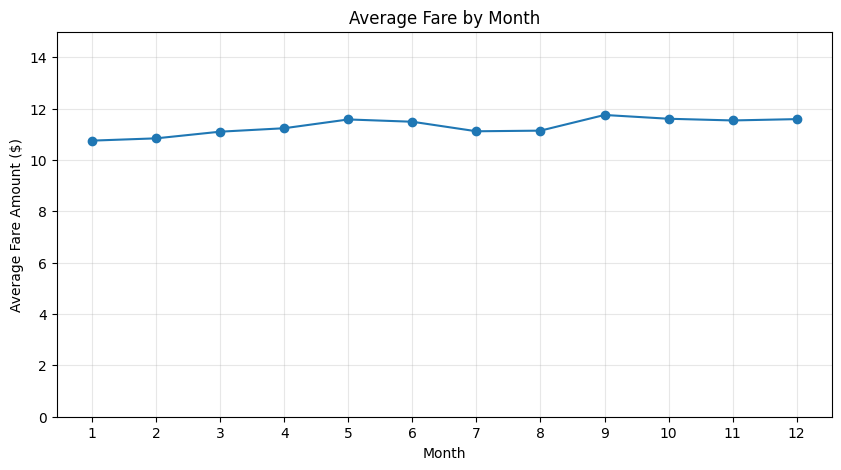

month
1     3.233769
2     3.221926
3     3.307973
4     3.349907
5     3.447632
6     3.411937
7     3.405151
8     3.432252
9     3.454997
10    3.399186
11    3.373645
12    3.367941
Name: distance, dtype: float64


In [65]:
# Group by month and get average fare
avg_fare_by_month = data.groupby('month')['fare_amount'].mean()

avg_fare_by_month.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Average Fare by Month')
plt.xlabel('Month')
plt.ylabel('Average Fare Amount ($)')
plt.xticks(range(1, 13))
plt.ylim(0, 15)
plt.grid(alpha=0.3)
plt.show()

# Check distance by month too to test whether any fare pattern here is a real seasonal effect or just a distance echo
# (same trap we caught with passenger_count, car_condition, hour, etc.)
print(data.groupby('month')['distance'].mean())

**Insight:** Average fare stays roughly flat across all 12 months, hovering close to $11 with only minor month-to-month variation. Average distance is similarly stable throughout the year (~3.2-3.45 km). Month has no meaningful effect on fare.

**Extra Q3**

Q: Has average fare changed over the years (2009-2015)?

Variables: year (numerical) vs fare_amount (numerical)

Chosen plot: Line chart , reason: year is ordered/sequential data

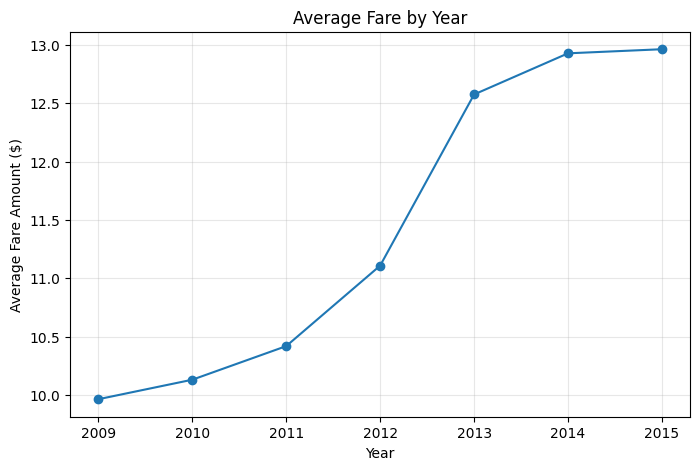

year
2009    3.219182
2010    3.277891
2011    3.359810
2012    3.390177
2013    3.443818
2014    3.464539
2015    3.436429
Name: distance, dtype: float64


In [57]:
avg_fare_by_year = data.groupby('year')['fare_amount'].mean()

avg_fare_by_year.plot(kind='line', marker='o', figsize=(8, 5))
plt.title('Average Fare by Year')
plt.xlabel('Year')
plt.ylabel('Average Fare Amount ($)')
plt.grid(alpha=0.3)
plt.show()

# Check distance by year ,if distance stayed flat while fare rose
# sharply, that confirms this is a real trend, not a distance artifact
print(data.groupby('year')['distance'].mean())

**Insight:** Average fare rose ~30% from 2009 (9.96) to 2015 (12.96), while average distance rose only ~7% over the same period. Since distance can't explain most of this increase, this is a genuine fare trend over time — likely reflecting inflation or fare rate increases — rather than people traveling farther. This is the first pattern in the analysis that isn't just a distance effect in disguise.

**Extra Q4**

Q: Do rush-hour trips (7-9AM, 5-7PM) differ from non-rush-hour trips in fare or distance?

Variables: is_rush_hour (categorical/binary) vs fare_amount, distance (numerical)

Chosen plot: Bar chart , reason: comparing average fare across two groups

              fare_amount  distance
is_rush_hour                       
0               11.485749  3.471105
1               10.900090  3.117894


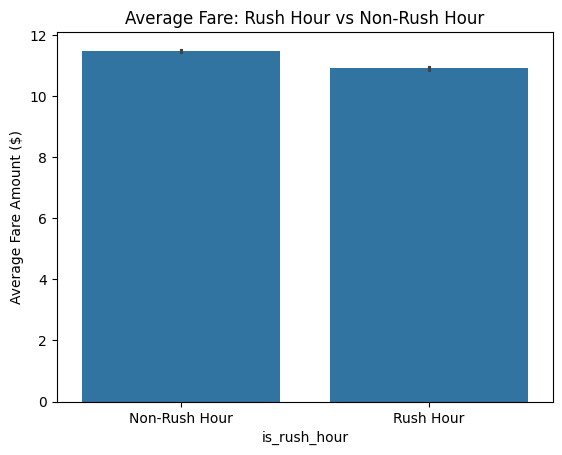

In [58]:
data['is_rush_hour'] = data['hour'].apply(
    lambda h: 1 if (7 <= h <= 9) or (17 <= h <= 19) else 0
)

# Compare both fare AND distance together to check whether any fare difference is explained by trip length rather than the rush-hour period itself
print(data.groupby('is_rush_hour')[['fare_amount', 'distance']].mean())

sns.barplot(data=data, x='is_rush_hour', y='fare_amount')
plt.xticks([0, 1], ['Non-Rush Hour', 'Rush Hour'])
plt.title('Average Fare: Rush Hour vs Non-Rush Hour')
plt.ylabel('Average Fare Amount ($)')
plt.show()

**Insight:** Rush-hour trips are slightly cheaper on average (10.90 vs 11.49) ,but this is explained by rush-hour trips also being shorter (3.12 vs 3.47km). There's no evidence of rush-hour surge pricing; rush-hour trips tend to be shorter local trips (likely commutes) rather than longer discretionary rides.